# Homework 6: CNNs



## Setup


In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.datasets import fashion_mnist

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 545
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

2026-05-28 19:24:04.905903: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.16.2


## Load Fashion MNIST


In [2]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Training images:", X_train_full.shape)
print("Training labels:", y_train_full.shape)
print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)
print("Pixel range before scaling:", X_train_full.min(), "to", X_train_full.max())

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Pixel range before scaling: 0 to 255


## Visualize Images


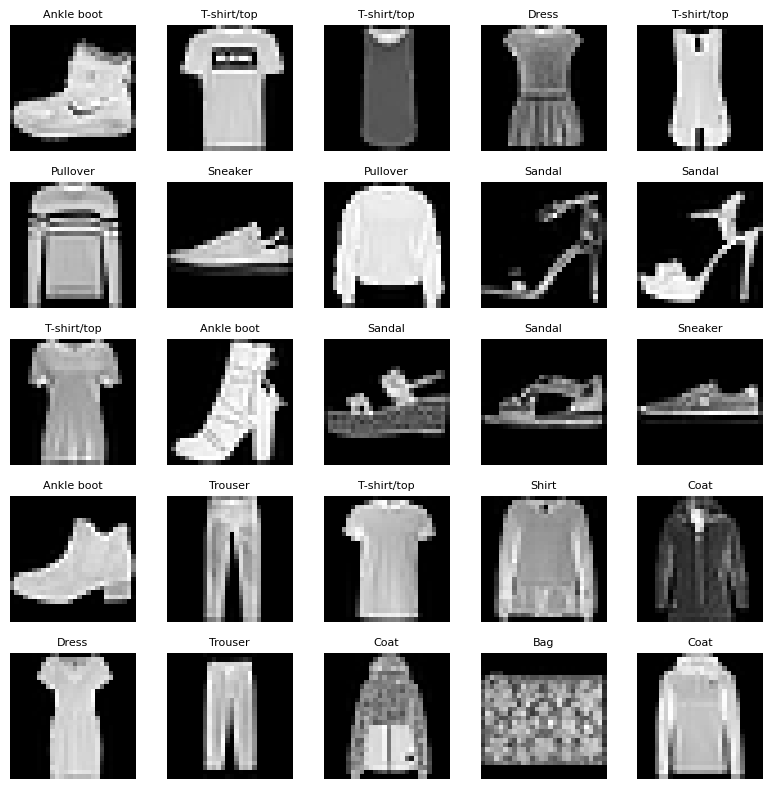

In [3]:
plt.figure(figsize=(8, 8))
for i in range(25):
    ax = plt.subplot(5, 5, i + 1)
    ax.imshow(X_train_full[i], cmap="gray")
    ax.set_title(class_names[y_train_full[i]], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Prepare Data


In [4]:
# Scale pixels and add grayscale channel dimension
X_train_full = (X_train_full.astype("float32") / 255.0)[..., np.newaxis]
X_test = (X_test.astype("float32") / 255.0)[..., np.newaxis]

# Hold out validation data from the original training set
val_size = 10000
X_val = X_train_full[-val_size:]
y_val = y_train_full[-val_size:]
X_train = X_train_full[:-val_size]
y_train = y_train_full[:-val_size]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (50000, 28, 28, 1) (50000,)
Validation: (10000, 28, 28, 1) (10000,)
Test: (10000, 28, 28, 1) (10000,)


## Helper Functions


In [5]:
def plot_history(history, title):
    history_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["accuracy"], label="Train")
    axes[0].plot(history_df["val_accuracy"], label="Validation")
    axes[0].set_title(f"{title}: Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(history_df["loss"], label="Train")
    axes[1].plot(history_df["val_loss"], label="Validation")
    axes[1].set_title(f"{title}: Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def evaluate_model(model, history, name):
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    best_val_acc = max(history.history["val_accuracy"])
    best_epoch = int(np.argmax(history.history["val_accuracy"]) + 1)
    train_acc_at_best = history.history["accuracy"][best_epoch - 1]

    return {
        "model": name,
        "epochs_run": len(history.history["loss"]),
        "best_epoch": best_epoch,
        "train_acc_at_best": train_acc_at_best,
        "best_val_acc": best_val_acc,
        "final_val_acc": val_acc,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "val_train_gap_at_best": train_acc_at_best - best_val_acc
    }


def fit_model(model, name, epochs=15, batch_size=128):
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    plot_history(history, name)
    return history, evaluate_model(model, history, name)


experiment_results = []
trained_models = {}

## Baseline CNN


In [6]:
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(64, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 59ms/step - accuracy: 0.8184 - loss: 0.5061 - val_accuracy: 0.8760 - val_loss: 0.3468
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.8858 - loss: 0.3205 - val_accuracy: 0.8940 - val_loss: 0.2947
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.9006 - loss: 0.2746 - val_accuracy: 0.9017 - val_loss: 0.2710
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.9122 - loss: 0.2427 - val_accuracy: 0.9052 - val_loss: 0.2586
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - accuracy: 0.9211 - loss: 0.2175 - val_accuracy: 0.9088 - val_loss: 0.2509
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.9295 - loss: 0.1953 - val_accuracy: 0.9132 - val_loss: 0.2486
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.9371 - loss: 0.1763 - val_accuracy: 0.9137 - val_loss: 0.2479
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.9443 - loss: 0.1585 - 

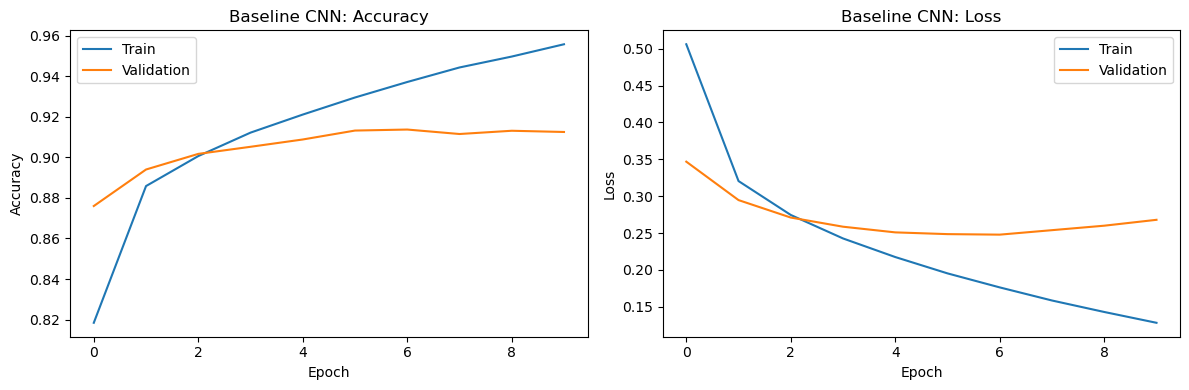

,model,epochs_run,best_epoch,train_acc_at_best,best_val_acc,final_val_acc,test_acc,test_loss,val_train_gap_at_best
0,Baseline CNN,10,7,0.93714,0.9137,0.9137,0.9033,0.263834,0.02344


In [7]:
baseline_history, baseline_metrics = fit_model(baseline_model, "Baseline CNN")
experiment_results.append(baseline_metrics)
trained_models["Baseline CNN"] = baseline_model
pd.DataFrame(experiment_results)

## Experiment 1: Dropout

This tests whether dropout helps reduce overfitting compared with the baseline.


Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.7913 - loss: 0.5760 - val_accuracy: 0.8631 - val_loss: 0.3693
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 64ms/step - accuracy: 0.8685 - loss: 0.3672 - val_accuracy: 0.8797 - val_loss: 0.3205
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.8856 - loss: 0.3188 - val_accuracy: 0.8891 - val_loss: 0.2938
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.8954 - loss: 0.2866 - val_accuracy: 0.8996 - val_loss: 0.2683
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.9051 - loss: 0.2641 - val_accuracy: 0.9072 - val_loss: 0.2513
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.9115 - loss: 0.2443 - val_accuracy: 0.9082 - val_loss: 0.2513
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.9185 - loss: 0.2261 - val_accuracy: 0.9137 - val_loss: 0.2309
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.9236 - loss: 0.2112 - 

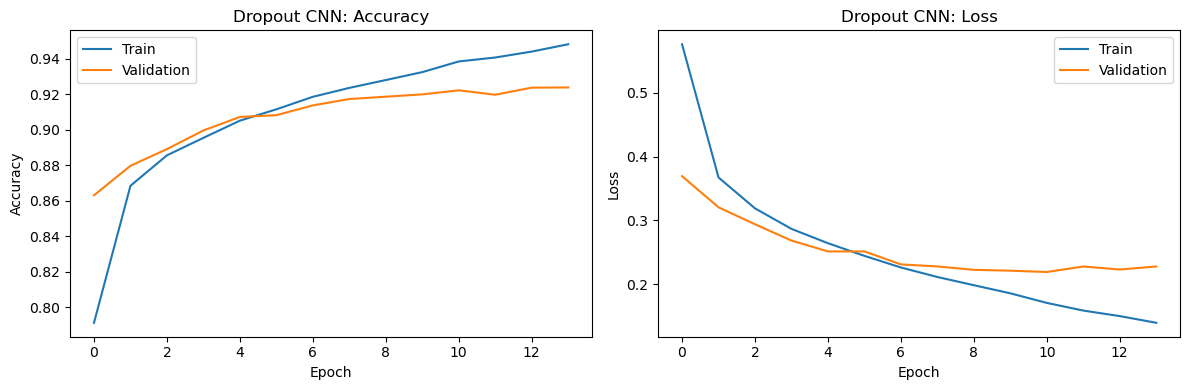

,model,epochs_run,best_epoch,train_acc_at_best,best_val_acc,final_val_acc,test_acc,test_loss,val_train_gap_at_best
0,Baseline CNN,10,7,0.93714,0.9137,0.9137,0.9033,0.263834,0.02344
1,Dropout CNN,14,14,0.94812,0.9238,0.9222,0.9158,0.241502,0.02432


In [8]:
def build_dropout_model(dropout_rate=0.35):
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

dropout_model = build_dropout_model()
dropout_history, dropout_metrics = fit_model(dropout_model, "Dropout CNN")
experiment_results.append(dropout_metrics)
trained_models["Dropout CNN"] = dropout_model
pd.DataFrame(experiment_results)

## Experiment 2: Batch Normalization

This tests whether batch normalization improves training stability and validation performance.


Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 113ms/step - accuracy: 0.8420 - loss: 0.4580 - val_accuracy: 0.7590 - val_loss: 0.6819
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 44s 113ms/step - accuracy: 0.8953 - loss: 0.2908 - val_accuracy: 0.8937 - val_loss: 0.2948
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 118ms/step - accuracy: 0.9126 - loss: 0.2442 - val_accuracy: 0.8999 - val_loss: 0.2787
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 119ms/step - accuracy: 0.9231 - loss: 0.2132 - val_accuracy: 0.8962 - val_loss: 0.2931
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 120ms/step - accuracy: 0.9313 - loss: 0.1887 - val_accuracy: 0.8974 - val_loss: 0.2847
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 119ms/step - accuracy: 0.9396 - loss: 0.1676 - val_accuracy: 0.8963 - val_loss: 0.2894


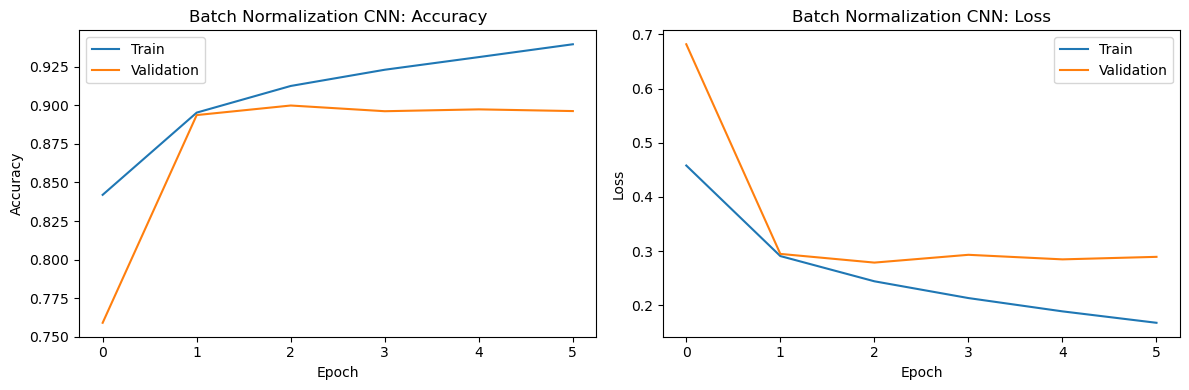

,model,epochs_run,best_epoch,train_acc_at_best,best_val_acc,final_val_acc,test_acc,test_loss,val_train_gap_at_best
0,Baseline CNN,10,7,0.93714,0.9137,0.9137,0.9033,0.263834,0.02344
1,Dropout CNN,14,14,0.94812,0.9238,0.9222,0.9158,0.241502,0.02432
2,Batch Normalization CNN,6,3,0.91258,0.8999,0.8999,0.8919,0.291692,0.01268


In [9]:
def build_batchnorm_model():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

batchnorm_model = build_batchnorm_model()
batchnorm_history, batchnorm_metrics = fit_model(batchnorm_model, "Batch Normalization CNN")
experiment_results.append(batchnorm_metrics)
trained_models["Batch Normalization CNN"] = batchnorm_model
pd.DataFrame(experiment_results)

## Experiment 3: Data Augmentation

This tests whether small image transformations improve generalization.


Epoch 1/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 69ms/step - accuracy: 0.7354 - loss: 0.7176 - val_accuracy: 0.8225 - val_loss: 0.4650
Epoch 2/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.8174 - loss: 0.4931 - val_accuracy: 0.8585 - val_loss: 0.3751
Epoch 3/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.8387 - loss: 0.4369 - val_accuracy: 0.8627 - val_loss: 0.3612
Epoch 4/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.8497 - loss: 0.4045 - val_accuracy: 0.8775 - val_loss: 0.3277
Epoch 5/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.8598 - loss: 0.3786 - val_accuracy: 0.8839 - val_loss: 0.3100
Epoch 6/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.8674 - loss: 0.3595 - val_accuracy: 0.8861 - val_loss: 0.3007
Epoch 7/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.8735 - loss: 0.3436 - val_accuracy: 0.8897 - val_loss: 0.2823
Epoch 8/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.8780 - loss: 0.3302 - 

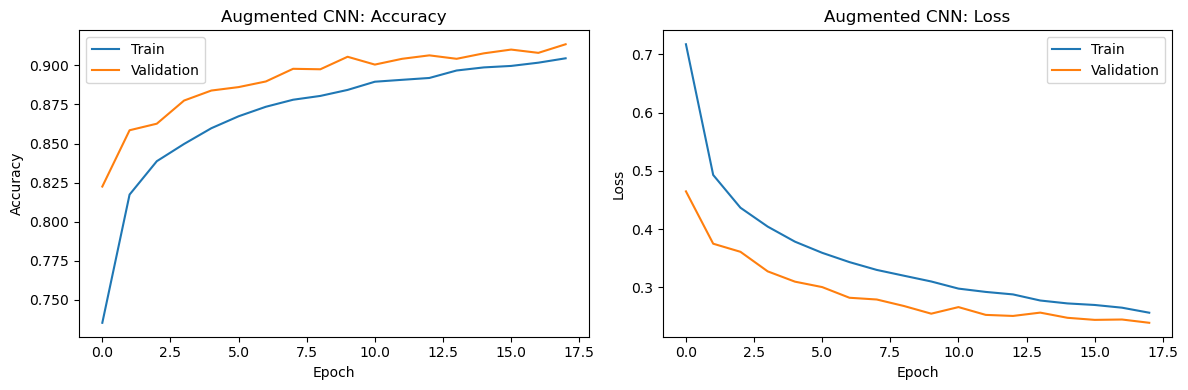

,model,epochs_run,best_epoch,train_acc_at_best,best_val_acc,final_val_acc,test_acc,test_loss,val_train_gap_at_best
0,Baseline CNN,10,7,0.93714,0.9137,0.9137,0.9033,0.263834,0.02344
1,Dropout CNN,14,14,0.94812,0.9238,0.9222,0.9158,0.241502,0.02432
2,Batch Normalization CNN,6,3,0.91258,0.8999,0.8999,0.8919,0.291692,0.01268
3,Augmented CNN,18,18,0.90452,0.9135,0.9135,0.9095,0.247889,-0.00898


In [10]:
def build_augmented_model():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.RandomTranslation(height_factor=0.08, width_factor=0.08, seed=SEED),
        layers.RandomZoom(height_factor=0.08, width_factor=0.08, seed=SEED),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

augmented_model = build_augmented_model()
augmented_history, augmented_metrics = fit_model(augmented_model, "Augmented CNN", epochs=18)
experiment_results.append(augmented_metrics)
trained_models["Augmented CNN"] = augmented_model
pd.DataFrame(experiment_results)

## Experiment 4: Wider CNN

This tests whether adding more filters improves performance enough to justify the extra complexity.


Epoch 1/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 102s 254ms/step - accuracy: 0.8163 - loss: 0.5109 - val_accuracy: 0.8823 - val_loss: 0.3141
Epoch 2/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 99s 253ms/step - accuracy: 0.8929 - loss: 0.3006 - val_accuracy: 0.8999 - val_loss: 0.2635
Epoch 3/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 98s 251ms/step - accuracy: 0.9123 - loss: 0.2456 - val_accuracy: 0.9128 - val_loss: 0.2330
Epoch 4/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 98s 250ms/step - accuracy: 0.9219 - loss: 0.2152 - val_accuracy: 0.9174 - val_loss: 0.2200
Epoch 5/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 99s 253ms/step - accuracy: 0.9306 - loss: 0.1897 - val_accuracy: 0.9158 - val_loss: 0.2301
Epoch 6/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 98s 251ms/step - accuracy: 0.9389 - loss: 0.1676 - val_accuracy: 0.9243 - val_loss: 0.2127
Epoch 7/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 98s 252ms/step - accuracy: 0.9457 - loss: 0.1458 - val_accuracy: 0.9285 - val_loss: 0.2171
Epoch 8/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 99s 254ms/step - accuracy: 0.9521 - loss: 

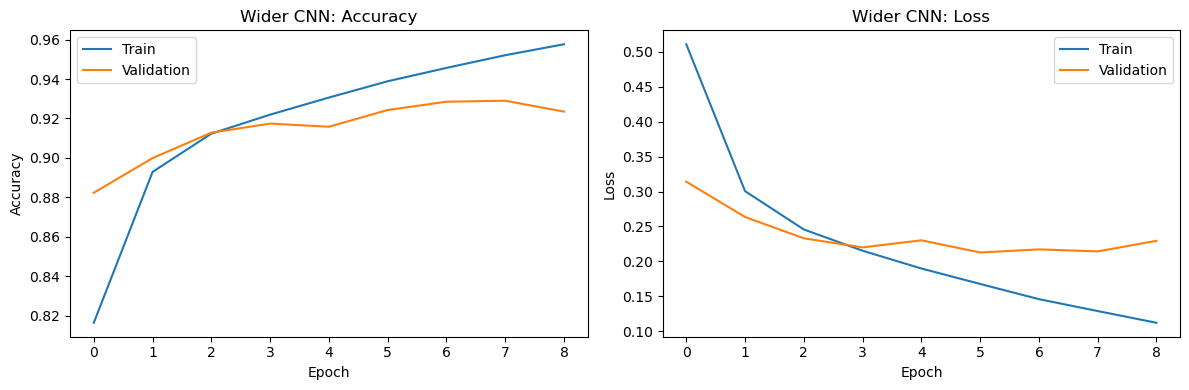

,model,epochs_run,best_epoch,train_acc_at_best,best_val_acc,final_val_acc,test_acc,test_loss,val_train_gap_at_best
4,Wider CNN,9,8,0.95210,0.9290,0.9243,0.9178,0.231730,0.02310
1,Dropout CNN,14,14,0.94812,0.9238,0.9222,0.9158,0.241502,0.02432
3,Augmented CNN,18,18,0.90452,0.9135,0.9135,0.9095,0.247889,-0.00898
0,Baseline CNN,10,7,0.93714,0.9137,0.9137,0.9033,0.263834,0.02344
2,Batch Normalization CNN,6,3,0.91258,0.8999,0.8999,0.8919,0.291692,0.01268


In [11]:
def build_wider_model():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(48, 3, activation="relu", padding="same"),
        layers.Conv2D(48, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Conv2D(96, 3, activation="relu", padding="same"),
        layers.Conv2D(96, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(160, activation="relu"),
        layers.Dropout(0.40),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

wider_model = build_wider_model()
wider_history, wider_metrics = fit_model(wider_model, "Wider CNN", epochs=18)
experiment_results.append(wider_metrics)
trained_models["Wider CNN"] = wider_model
pd.DataFrame(experiment_results).sort_values("test_acc", ascending=False)

## Compare Manual Experiments


In [12]:
results_df = pd.DataFrame(experiment_results).sort_values("test_acc", ascending=False)
results_df.style.format({
    "train_acc_at_best": "{:.4f}",
    "best_val_acc": "{:.4f}",
    "final_val_acc": "{:.4f}",
    "test_acc": "{:.4f}",
    "test_loss": "{:.4f}",
    "val_train_gap_at_best": "{:.4f}"
})

,model,epochs_run,best_epoch,train_acc_at_best,best_val_acc,final_val_acc,test_acc,test_loss,val_train_gap_at_best
4,Wider CNN,9,8,0.9521,0.9290,0.9243,0.9178,0.2317,0.0231
1,Dropout CNN,14,14,0.9481,0.9238,0.9222,0.9158,0.2415,0.0243
3,Augmented CNN,18,18,0.9045,0.9135,0.9135,0.9095,0.2479,-0.0090
0,Baseline CNN,10,7,0.9371,0.9137,0.9137,0.9033,0.2638,0.0234
2,Batch Normalization CNN,6,3,0.9126,0.8999,0.8999,0.8919,0.2917,0.0127


## Optuna Tuning

Optuna searches across model width, dense units, dropout, learning rate, batch normalization, augmentation, L2 regularization, and batch size.


In [13]:
try:
    import optuna
except ModuleNotFoundError:
    %pip install optuna -q
    import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS = 12
TUNING_EPOCHS = 10

In [16]:
import optuna
from tensorflow import keras
from tensorflow.keras import layers, regularizers



def build_tuned_model(trial):
    # smaller but still strong search space
    filters_1 = trial.suggest_categorical("filters_1", [32, 48])
    filters_2 = trial.suggest_categorical("filters_2", [64, 96])
    dense_units = trial.suggest_categorical("dense_units", [128, 192])
    dropout_rate = trial.suggest_float("dropout_rate", 0.20, 0.40, step=0.10)
    learning_rate = trial.suggest_float("learning_rate", 5e-4, 3e-3, log=True)
    use_batchnorm = trial.suggest_categorical("use_batchnorm", [True, False])
    l2_strength = trial.suggest_categorical("l2_strength", [0.0, 1e-5])

    model = keras.Sequential()
    model.add(layers.Input(shape=(28, 28, 1)))

    for filters in [filters_1, filters_2]:
        model.add(layers.Conv2D(
            filters,
            kernel_size=3,
            padding="same",
            use_bias=not use_batchnorm,
            kernel_regularizer=regularizers.l2(l2_strength) if l2_strength else None
        ))

        if use_batchnorm:
            model.add(layers.BatchNormalization())

        model.add(layers.Activation("relu"))
        model.add(layers.MaxPooling2D(2))

    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation="relu"))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def objective(trial):
    model = build_tuned_model(trial)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=2,
            mode="max",
            restore_best_weights=True
        )
    ]

    if USE_PRUNING:
        callbacks.append(TFKerasPruningCallback(trial, "val_accuracy"))

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=TUNING_EPOCHS,
        batch_size=128,   # fixed batch size usually speeds things up
        callbacks=callbacks,
        verbose=0
    )

    return max(history.history["val_accuracy"])


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=3,
        n_warmup_steps=2
    )
)

study.optimize(objective, n_trials=N_TRIALS)

print("Best validation accuracy:", study.best_value)
print("Best parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Best validation accuracy: 0.9223999977111816
Best parameters:
  filters_1: 32
  filters_2: 64
  dense_units: 192
  dropout_rate: 0.4
  learning_rate: 0.0010439682102246733
  use_batchnorm: False
  l2_strength: 0.0


## Final Tuned Model


Epoch 1/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.8348 - loss: 0.4551 - val_accuracy: 0.8885 - val_loss: 0.3038
Epoch 2/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.8912 - loss: 0.3018 - val_accuracy: 0.9003 - val_loss: 0.2666
Epoch 3/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9065 - loss: 0.2568 - val_accuracy: 0.9103 - val_loss: 0.2402
Epoch 4/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.9161 - loss: 0.2238 - val_accuracy: 0.9132 - val_loss: 0.2389
Epoch 5/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9254 - loss: 0.2003 - val_accuracy: 0.9206 - val_loss: 0.2235
Epoch 6/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.9345 - loss: 0.1770 - val_accuracy: 0.9213 - val_loss: 0.2247
Epoch 7/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.9401 - loss: 0.1595 - val_accuracy: 0.9200 - val_loss: 0.2332
Epoch 8/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.9458 -

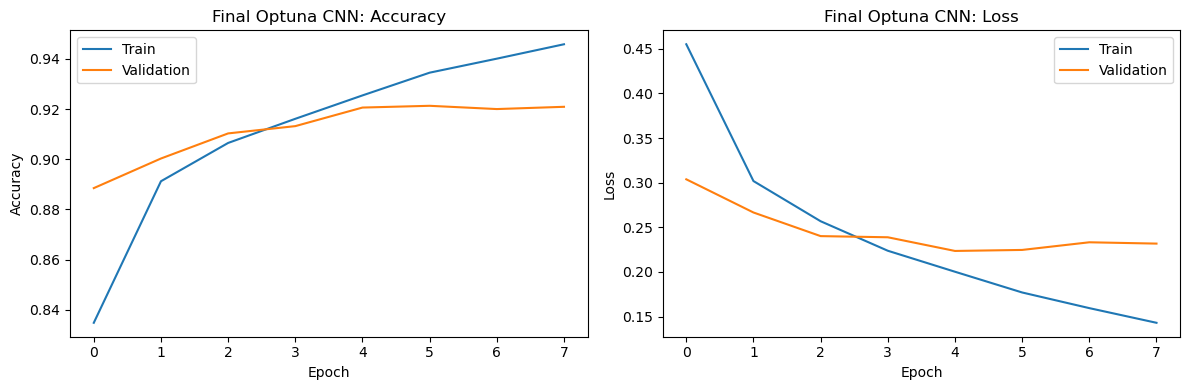

,model,epochs_run,best_epoch,train_acc_at_best,best_val_acc,final_val_acc,test_acc,test_loss,val_train_gap_at_best
4,Wider CNN,9,8,0.95210,0.9290,0.9243,0.9178,0.231730,0.02310
1,Dropout CNN,14,14,0.94812,0.9238,0.9222,0.9158,0.241502,0.02432
5,Final Optuna CNN,8,6,0.93450,0.9213,0.9206,0.9147,0.243344,0.01320
3,Augmented CNN,18,18,0.90452,0.9135,0.9135,0.9095,0.247889,-0.00898
0,Baseline CNN,10,7,0.93714,0.9137,0.9137,0.9033,0.263834,0.02344
2,Batch Normalization CNN,6,3,0.91258,0.8999,0.8999,0.8919,0.291692,0.01268


In [18]:
class FixedTrial:
    def __init__(self, params):
        self.params = params
    def suggest_categorical(self, name, choices):
        return self.params[name]
    def suggest_float(self, name, low, high, step=None, log=False):
        return self.params[name]

best_trial = FixedTrial(study.best_params)
final_model = build_tuned_model(best_trial)
final_history, final_metrics = fit_model(
    final_model,
    "Final Optuna CNN",
    epochs=25,
    batch_size=study.best_params.get("batch_size", 32)

)

experiment_results.append(final_metrics)
trained_models["Final Optuna CNN"] = final_model
results_df = pd.DataFrame(experiment_results).sort_values("test_acc", ascending=False)
results_df

## Final Test Evaluation


              precision    recall  f1-score   support

 T-shirt/top       0.83      0.91      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.87      0.85      0.86      1000
       Dress       0.92      0.93      0.92      1000
        Coat       0.85      0.87      0.86      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.79      0.71      0.75      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



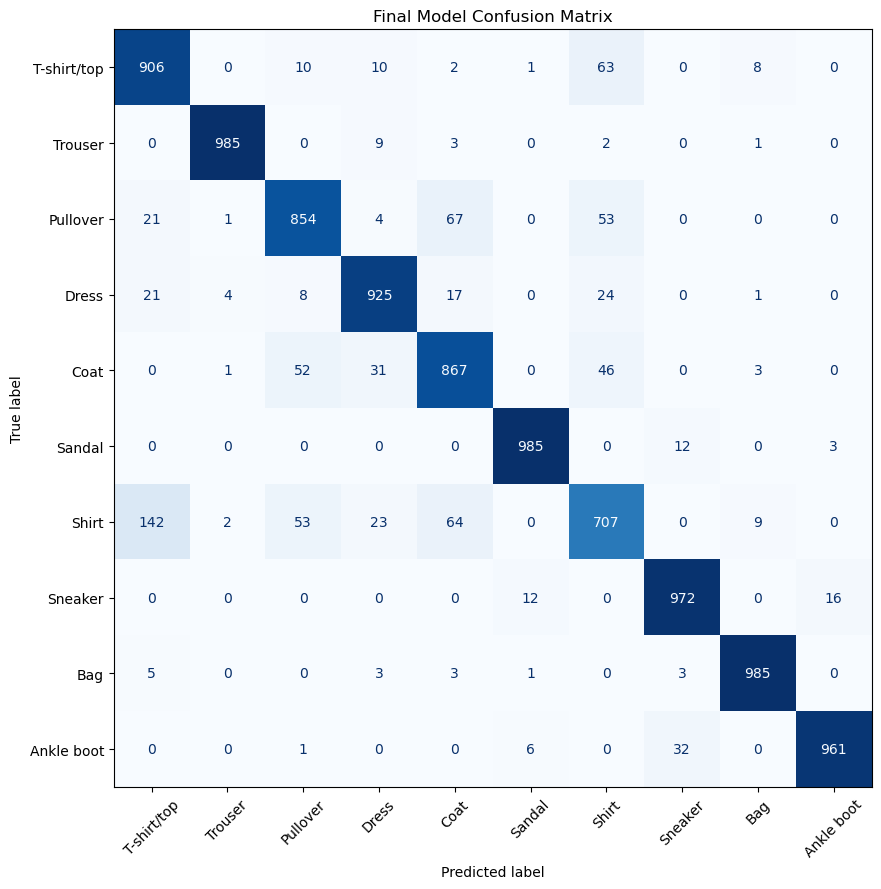

In [19]:
y_prob = final_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(9, 9))
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
display.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
ax.set_title("Final Model Confusion Matrix")
plt.tight_layout()
plt.show()

## Analysis

My final CNN performed well on the held-out test set, with an overall test accuracy of about 91%. The best manual model was the wider CNN, which reached 0.9178 test accuracy, compared to 0.9033 for the baseline CNN. This showed that increasing the number of filters helped the model learn stronger image patterns. The dropout CNN was also strong at 0.9158, so regularization helped keep performance close while reducing some overfitting risk.
The main tradeoff I noticed was between model complexity and generalization. The wider CNN had the highest test accuracy, but it also had a larger training-validation gap, which suggests mild overfitting. The Optuna model did not beat the wider CNN, but it still performed well at 0.9147 and seemed more balanced. Batch normalization did not help in my experiments, and augmentation only slightly improved over the baseline, probably because Fashion MNIST images are already pretty standardized.
Looking at the test results, the model did best on visually distinct categories like trousers, bags, sandals, sneakers, and ankle boots. The hardest category was shirts, which makes sense because shirts look similar to T-shirts, coats, and pullovers. Overall, the model was strong, but most of its errors came from clothing classes that naturally overlap visually.
In the future, my personal workflow for CNNs would be to start with a simple baseline model first, then test one change at a time, like wider layers, dropout, batch normalization, or augmentation. I would prioritize validation accuracy, test accuracy, and the training-validation gap instead of only picking the most complex model. After that, I would use Optuna or another tuning method to fine-tune the strongest setup, but I would keep the search space small so it does not take too long.
